# Regresión Lineal: Descenso de Gradiente desde Cero
### *Implementación manual con NumPy (sin librerías de ML)*

---

En este notebook se implementa el descenso del gradiente **completamente desde cero**. Puede haber pequeñas variaciones o elecciones de diseño en las fórmulas, pero el método y los resultados son los mismos. El objetivo es entender de verdad qué pasa por dentro cuando entrenamos un modelo de regresión lineal.

Utilizaré un dataset sencillo de **precios de casas** para verlo en acción.

## 1. El Gradiente ∇f: Repaso rápido

El gradiente $\vec{\nabla}f$ es un vector que apunta en la **dirección donde la función crece más rápido** (mayor pendiente).

$$\vec{\nabla}f = \left( \frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \dots, \frac{\partial f}{\partial x_n} \right)$$

Si queremos **minimizar** una función, nos movemos en la dirección **opuesta** al gradiente. Esa es la idea central del descenso de gradiente.

## 2. La Función de coste $J(\theta)$

Para regresión lineal, la función de coste es el **error cuadrático medio** (dividido entre 2 para que la derivada quede más simple):

$$J(\theta) = \frac{1}{2} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2$$

donde:
- $m$ = número de ejemplos de entrenamiento
- $h_\theta(x) = \theta_0 + \theta_1 x_1 + \dots + \theta_n x_n$ = predicción del modelo
- $y^{(i)}$ = valor real

**¿Por qué cuadrado y no valor absoluto?**

Con $|x|$ tendríamos problemas en el punto mínimo (la derivada no existe). Con $x^2$ la función es suave (parábola), diferenciable en todos lados, y los errores grandes se penalizan más. Además, si buscáramos una implementación básica: $\sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)$ los errores positivos y negativos se cancelarían entre sí, ocultando el margen de fallo real del modelo.



In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### 2.1 Visualización: por qué x² y no |x|

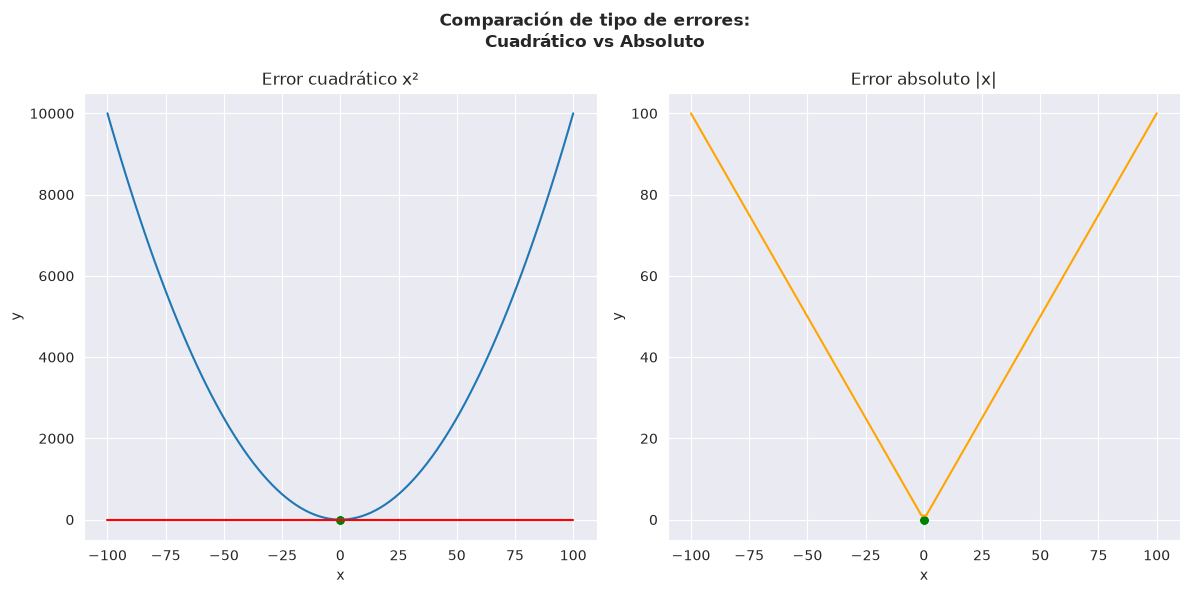

In [36]:
x_par = np.linspace(-100,100, 100)
y_par = x_par**2

x_abs = np.linspace(-100,100, 100)
y_abs = np.abs(x_abs)
sns.set_style("darkgrid")
fig, axes = plt.subplots(1,2,figsize=(12,6))

fig.suptitle("Comparación de tipo de errores:\nCuadrático vs Absoluto", fontweight="bold")

sns.scatterplot(x=[0],y=[0], ax=axes[0], color="green", s=50) # Punto mínimo
sns.lineplot(x=x_par,y=y_par, ax=axes[0])
axes[0].set_title("Error cuadrático x²")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

sns.scatterplot(x=[0],y=[0], ax=axes[1], color="green", s=50) # Punto mínimo
sns.lineplot(x=x_abs,y=y_abs, ax=axes[1], color="orange")
axes[1].set_title("Error absoluto |x|")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

# Dibujamos la recta tangente de x²
sns.lineplot(x=np.linspace(-100,100,2),y=[0]*2, ax=axes[0], color="red")  # Pendiente 0


plt.tight_layout()
plt.show()


1. Con $\vert{}x\vert{}$, en $x = 0$ las derivadas laterales no coinciden (las pendientes por la izquierda y derecha son $-1$ y $+1$), por lo que no existe una única tangente y el gradiente no está definido en ese punto.
2. Con $x^2$ hay una única tangente en cada punto, por lo tanto el gradiente siempre está bien definido.

Además, al elevar el error al cuadrado, tanto los errores positivos como los negativos contribuyen de forma positiva a la función de coste, evitando que unos se cancelen con otros. Esto permite medir el error total de forma consistente y penaliza especialmente los errores grandes.

## 3. La Regla de Actualización

La regla de actualización del descenso de gradiente es:

$$\boxed{\theta_j := \theta_j - \alpha \frac{\partial}{\partial \theta_j} J(\theta)}$$

donde $\alpha$ (alpha) es el **learning rate**, en el 99% de los casos usar **0.01** es un buen punto de partida.

La intuición: nos movemos en la dirección opuesta al gradiente (cuesta abajo), un paso de tamaño $\alpha$.

## 4. Demostración: Calculando la derivada de $J(\theta)$

Partimos de:

$$\theta_j := \theta_j - \alpha \frac{\partial}{\partial \theta_j} J(\theta) = \theta_j - \alpha \frac{\partial}{\partial \theta_j} \left[ \frac{1}{2} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2 \right]$$

Aplicando la regla de la cadena:

$$= \theta_j - \alpha \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) \cdot \frac{\partial}{\partial \theta_j} \left( h_\theta(x^{(i)}) - y^{(i)} \right)$$

Como $h_\theta(x) = \theta_0 x_0 + \theta_1 x_1 + \dots + \theta_n x_n$, derivando respecto a $\theta_j$:

$$\frac{\partial}{\partial \theta_j} \left( \theta_0 x_0 + \theta_1 x_1 + \dots + \theta_n x_n - y \right) = x_j$$

Todo lo demás es constante respecto a $\theta_j$, así que su derivada es 0. Nos queda:

$$\boxed{\theta_j := \theta_j - \alpha \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) \cdot x_j^{(i)}}$$

Esa es la fórmula que vamos a implementar

## 5. Dataset: Precios de casas

Vamos a crear un dataset sintético sencillo: **metros cuadrados -> precio en miles de €**.

In [37]:
df = pd.read_csv("casas.csv")
df = df[["GrLivArea", "SalePrice"]]
df.drop_duplicates()
df.head(2)

,GrLivArea,SalePrice
0,1710,208500
1,1262,181500


Para practicar y tener claras las matemáticas nos bastará con este *dataset* sencillo, los filtramos para tener solamente los features de $m^2$ y precio.

## 6. Preprocesado: Normalización de features

Antes de aplicar descenso de gradiente conviene **normalizar** los datos. Esto hace que el gradiente tenga escalas similares en todas las dimensiones y converge mucho más rápido.

In [38]:
df["GrLivArea"] = df["GrLivArea"].astype(float)
df["SalePrice"] = df["SalePrice"].astype(float)

train_min = df.iloc[:1450].min()
train_max = df.iloc[:1450].max()

df = (df - train_min) / (train_max - train_min)
df.head()

,GrLivArea,SalePrice
0,0.259231,0.241078
1,0.174830,0.203583
2,0.273549,0.261908
3,0.260550,0.145952
4,0.351168,0.298709


Se observa que los valores se han normalizado de manera correcta.

## 7. Implementación: Funciones Clave

Implementamos las tres piezas fundamentales:
1. **Hipótesis** $h_\theta(x)$
2. **Función de coste** $J(\theta)$  
3. **Gradiente** $\frac{\partial J}{\partial \theta_j}$

#### Hipótesis $h_\theta(x)$

In [39]:
def hipotesis(X, theta):
    return np.dot(X,theta)

$$h_\theta(x) = \theta_0 x_0 + \theta_1 x_1 + \dots + \theta_n x_n = X\theta$$

Es simplemente el producto de la matriz de features $X$ por el vector de parámetros $\theta$. Cada fila de $X$ es un ejemplo (una casa), y el resultado es la predicción del modelo para ese ejemplo. Gracias a la columna de 1s añadida en $X$, el término independiente $\theta_0$ queda incluido en el mismo producto matricial, sin necesidad de tratarlo aparte.


#### Función de coste $J(\theta)$

In [ ]:
def coste(X, y, theta):
    m = len(y)
    errores = hipotesis(X, theta) - y
    return (1 / (2))*np.sum(errores**2)

$$J(\theta) = \frac{1}{2}\sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2$$

Es el error cuadrático medio entre las predicciones $h_\theta(x^{(i)})$ y los valores reales $y^{(i)}$, dividido entre $2$. El $\frac{1}{2}$ es solo por comodidad matemática (simplifica la derivada al aplicar la regla de la cadena).


#### Gradiente $\nabla J(\theta)$

Este cálculo solo es utilizado por el desciente de gradiente de tipo batch.

In [41]:
def gradiente(X, y, theta):
    return X.T @ (hipotesis(X, theta) - y)

$$\frac{\partial J}{\partial \theta_j} = \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) \cdot x_j^{(i)}$$

En forma vectorizada, para todos los $\theta_j$ a la vez:

$$\nabla J(\theta) = X^T \left( h_\theta(X) - y \right)$$

Esta es la derivada parcial de $J(\theta)$ respecto a cada parámetro $\theta_j$ (la demostración completa está en la sección 4). Vectorizarlo como $X^T \cdot \text{errores}$ evita tener que iterar en un bucle sobre cada feature $j$: NumPy calcula el gradiente completo de una sola vez.


## 8. Los tres tipos de Descenso de Gradiente

Hay tres variantes principales, como aparece en las notas:

| Variante | Descripción | Actualización |
|----------|-------------|---------------|
| **Batch** | Usa todos los ejemplos en cada paso | $\theta_j := \theta_j - \alpha \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)}) \cdot x_j^{(i)}$ |
| **Estocástico (SGD)** | Usa un solo ejemplo a la vez | $\theta_j := \theta_j - \alpha (h_\theta(x^{(i)}) - y^{(i)}) \cdot x_j^{(i)}$ |
| **Mini-Batch** | Mezcla de los dos, por bloques (potencias de 2) | $\theta_j := \theta_j - \alpha \sum_{i=a}^{b} (h_\theta(x^{(i)}) - y^{(i)}) \cdot x_j^{(i)}$ |

Vamos a implementar los tres:

In [42]:
def batch(alfa, theta, X, y, n_iteraciones=1000):
    for _ in range(n_iteraciones):
        aux = theta.copy()
        grad = gradiente(X,y,theta)
        for i,value in enumerate(theta):
            aux[i] = theta[i] - alfa*grad[i]
        theta = aux
    return theta

def estocástico(alfa, theta, X, y, n_iteraciones=100000):
    for _ in range(n_iteraciones):   # Añadimos mas iteraciones al no probar todos los ejemplos
        aux = theta.copy()
        ejemplo = np.random.randint(0, len(X))
        valor_real = y[ejemplo]
        for i,value in enumerate(theta):
            aux[i] = theta[i] - alfa*((hipotesis(X[ejemplo], theta) - valor_real)*X[ejemplo][i])
        theta = aux
    return theta


def mini_batch(alfa, theta, X, y, tam_batch=32, n_iteraciones=10000):
    theta = theta.copy()
    m = len(X)
    for _ in range(n_iteraciones):
        indices = np.random.choice(m, tam_batch, replace=False)  # k índices al azar, sin repetir
        X_batch = X[indices]
        y_batch = y[indices]
        grad = gradiente(X_batch, y_batch, theta)
        theta = theta - alfa*grad
    return theta

## 9. Entrenamiento y Comparación

In [43]:
# Construimos la matriz X
tamaño = df["GrLivArea"].values[:1450]
X = np.column_stack((np.ones(1450), tamaño))
y = df["SalePrice"].values[:1450]
# Construimos el vector theta
theta = np.ones(2)
test = pd.read_csv("casas.csv")

x_min = train_min["GrLivArea"]
x_max = train_max["GrLivArea"]
y_min = train_min["SalePrice"]
y_max = train_max["SalePrice"]


Una vez preparados los datos, procedemos a ejecutar los tres algoritmos

### Batch

In [44]:
def ejecutar_batch():
    print("---- Descenso de gradiente por BATCH (por lotes) ----")
    recta = batch(0.001, theta, X, y)
    total_error = 0
    for j in range(1450, 1460):
        grlivarea_real = test.iloc[j]["GrLivArea"]
        grlivarea_norm = (grlivarea_real - x_min) / (x_max - x_min)
        precio = hipotesis(theta=recta, X=np.array([1, grlivarea_norm]))
        precio_desnormalizado = (precio)*(y_max - y_min) + y_min
        original = test.iloc[j]["SalePrice"]
        error = abs(precio_desnormalizado - original)
        total_error += error
        print(f"El precio predicho es {precio_desnormalizado}, el precio real es {original}, la diferencia es {error}")
    print(f"\nEl error medio de Batch es {total_error/10}")
    return recta, total_error/10

In [45]:
recta_batch, error_batch = ejecutar_batch()

---- Descenso de gradiente por BATCH (por lotes) ----
El precio predicho es 210593.5357441284, el precio real es 136000, la diferencia es 74593.5357441284
El precio predicho es 187650.03990176241, el precio real es 287090, la diferencia es 99439.96009823759
El precio predicho es 133400.4656202802, el precio real es 145000, la diferencia es 11599.534379719786
El precio predicho es 140690.9222430881, el precio real es 84500, la diferencia es 56190.922243088105
El precio predicho es 149375.14263202104, el precio real es 185000, la diferencia es 35624.857367978955
El precio predicho es 195047.70912196452, el precio real es 175000, la diferencia es 20047.709121964523
El precio predicho es 240720.275611908, el precio real es 210000, la diferencia es 30720.275611908
El precio predicho es 269346.0391161684, el precio real es 266500, la diferencia es 2846.0391161683947
El precio predicho es 134043.7412046456, el precio real es 142125, la diferencia es 8081.258795354399
El precio predicho es 153

### SGD

In [46]:
def ejecutar_sgd():
    print("---- Descenso de gradiente por SGD (estocástico) ----")
    recta = estocástico(0.001, theta, X, y)
    total_error = 0
    for j in range(1450, 1460):
        grlivarea_real = test.iloc[j]["GrLivArea"]
        grlivarea_norm = (grlivarea_real - x_min) / (x_max - x_min)
        precio = hipotesis(theta=recta, X=np.array([1, grlivarea_norm]))
        precio_desnormalizado = (precio) * (y_max - y_min) + y_min
        original = test.iloc[j]["SalePrice"]
        error = abs(precio_desnormalizado - original)
        total_error += error
        print(f"El precio predicho es {precio_desnormalizado}, el precio real es {original}, la diferencia es {error}")
    print(f"\nEl error medio de SGD es {total_error/10}")
    return recta, total_error/10

In [47]:
recta_sgd, error_sgd = ejecutar_sgd()

---- Descenso de gradiente por SGD (estocástico) ----
El precio predicho es 212231.79496845382, el precio real es 136000, la diferencia es 76231.79496845382
El precio predicho es 189468.82908758763, el precio real es 287090, la diferencia es 97621.17091241237
El precio predicho es 135646.11536927777, el precio real es 145000, la diferencia es 9353.884630722227
El precio predicho es 142879.2073314222, el precio real es 84500, la diferencia es 58379.20733142219
El precio predicho es 151495.0962863295, el precio real es 185000, la diferencia es 33504.9037136705
El precio predicho es 196808.29004917532, el precio real es 175000, la diferencia es 21808.290049175324
El precio predicho es 242121.48381202112, el precio real es 210000, la diferencia es 32121.48381202112
El precio predicho es 270522.0066633822, el precio real es 266500, la diferencia es 4022.006663382228
El precio predicho es 136284.32936593756, el precio real es 142125, la diferencia es 5840.670634062437
El precio predicho es 1

### Mini-Batch

In [48]:
def ejecutar_mini_batch():
    print("---- Descenso de gradiente por MIN-BATCH ----")
    recta = mini_batch(0.001, theta, X, y, tam_batch=64)
    total_error = 0
    for j in range(1450, 1460):
        grlivarea_real = test.iloc[j]["GrLivArea"]
        grlivarea_norm = (grlivarea_real - x_min) / (x_max - x_min)
        precio = hipotesis(theta=recta, X=np.array([1, grlivarea_norm]))
        precio_desnormalizado = (precio)*(y_max - y_min) + y_min
        original = test.iloc[j]["SalePrice"]
        error = abs(precio_desnormalizado - original)
        total_error += error
        print(f"El precio predicho es {precio_desnormalizado}, el precio real es {original}, la diferencia es {error}")
    print(f"\nEl error medio de MIN-BATCH es {total_error/10}")
    return recta, total_error/10

In [49]:
recta_mini_batch, error_mini_batch = ejecutar_mini_batch()

---- Descenso de gradiente por MIN-BATCH ----
El precio predicho es 211663.78054132123, el precio real es 136000, la diferencia es 75663.78054132123
El precio predicho es 188584.51290592138, el precio real es 287090, la diferencia es 98505.48709407862
El precio predicho es 134013.9081231535, el precio real es 145000, la diferencia es 10986.091876846505
El precio predicho es 141347.50718486938, el precio real es 84500, la diferencia es 56847.50718486938
El precio predicho es 150083.11783191323, el precio real es 185000, la diferencia es 34916.88216808677
El precio predicho es 196025.95901266244, el precio real es 175000, la diferencia es 21025.95901266244
El precio predicho es 241968.8001934117, el precio real es 210000, la diferencia es 31968.800193411706
El precio predicho es 270763.9612151489, el precio real es 266500, la diferencia es 4263.961215148913
El precio predicho es 134660.9903933049, el precio real es 142125, la diferencia es 7464.009606695094
El precio predicho es 153857.7

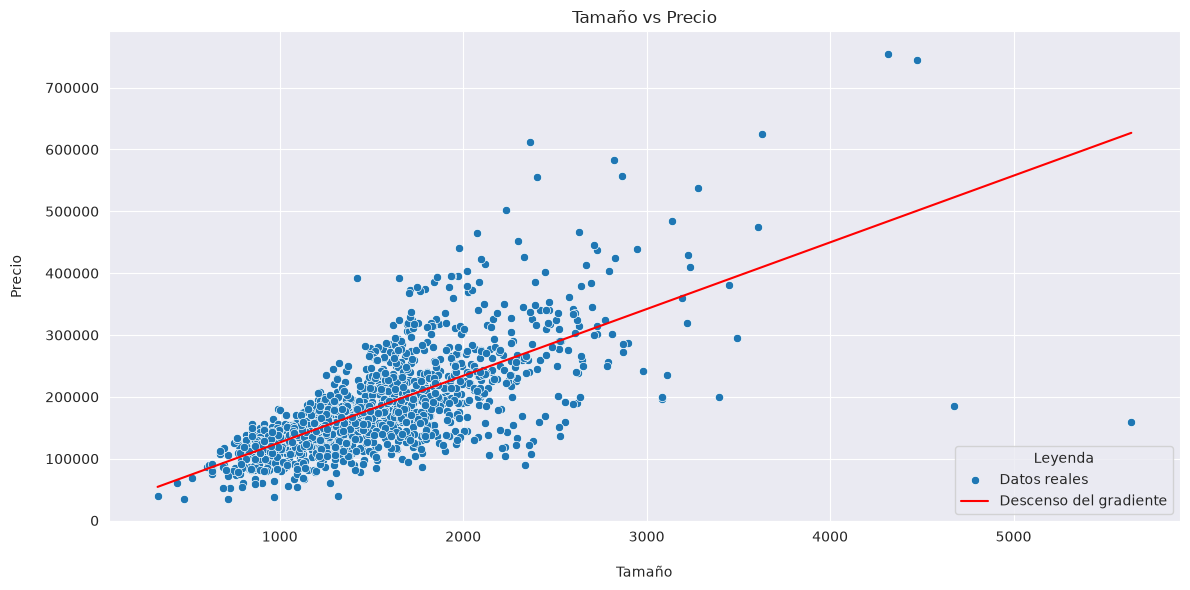

In [50]:
precios = test["SalePrice"].values
tamaño = test["GrLivArea"].values

plt.figure(figsize=(12,6))
sns.scatterplot(x=tamaño, y=precios, label="Datos reales")
plt.title("Tamaño vs Precio")
plt.xlabel("Tamaño", labelpad=15)
plt.ylabel("Precio", labelpad=15)

# Recta del descenso de gradiente
x_min = test["GrLivArea"].min()
x_max = test["GrLivArea"].max()
y_min = test["SalePrice"].min()
y_max = test["SalePrice"].max()
x = np.linspace(test["GrLivArea"].min(), test["GrLivArea"].max(), 100)
x_norm = (x - x_min) / (x_max - x_min)
y_norm = recta_mini_batch[0] + recta_mini_batch[1]*x_norm
y = y_norm*(y_max - y_min) + y_min
sns.lineplot(x=x, y=y, color="red", label="Descenso del gradiente")
plt.legend(title="Leyenda",loc="lower right")
plt.tight_layout()
plt.show()

## 10. Visualización de la Superficie de Coste J(θ)

Una de las visualizaciones más importantes: la superficie que intentamos minimizar, y el camino que sigue el gradiente.

Theta final: [2.17742491e-16 7.08624478e-01]
Coste final: 363.4314853015831


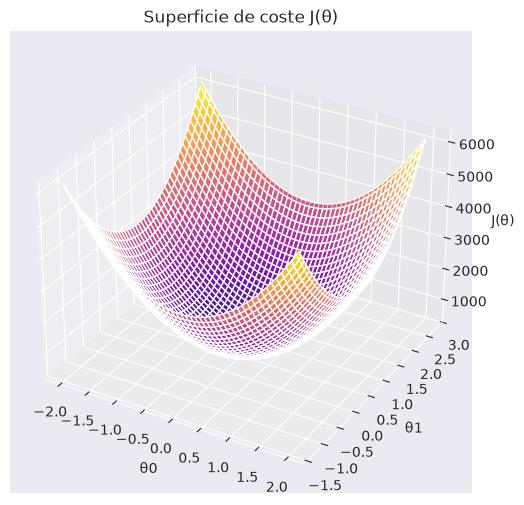

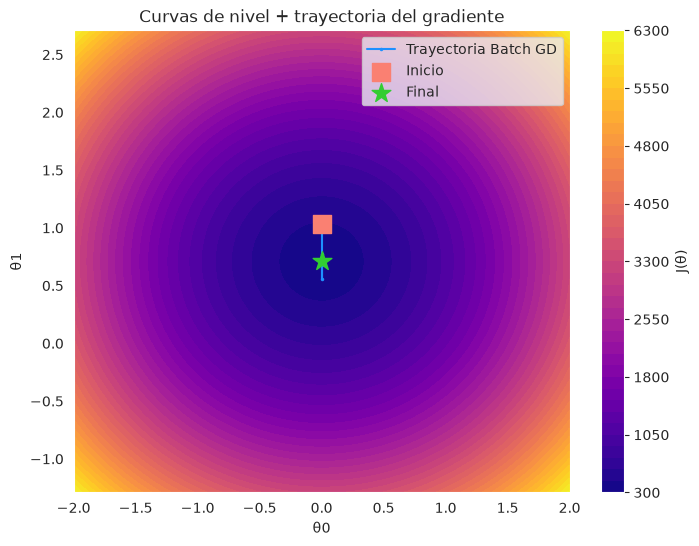

In [51]:
datos = pd.read_csv("casas.csv")

x_feature = datos['GrLivArea'].values.astype(float)
y_real = datos['SalePrice'].values.astype(float)
m = len(y_real)

x_mean, x_std = x_feature.mean(), x_feature.std()
y_mean, y_std = y_real.mean(), y_real.std()

x_feature_norm = (x_feature - x_mean) / x_std
y_norm = (y_real - y_mean) / y_std

X = np.column_stack((np.ones(m), x_feature_norm))
y = y_norm

def descenso_gradiente(X, y, theta_inicial, alpha, n_iteraciones):
    theta = theta_inicial.copy()
    historial_coste = []
    historial_theta = []
    for i in range(n_iteraciones):
        grad = gradiente(X, y, theta)
        theta = theta - alpha*grad
        historial_coste.append(coste(X, y, theta))
        historial_theta.append(theta.copy())
    return theta, historial_coste, historial_theta

theta_inicial = np.array([0.0, 0.0])
alpha = 0.001
n_iteraciones = 500

theta_final, historial_coste, historial_theta = descenso_gradiente(X, y, theta_inicial, alpha, n_iteraciones)
historial_theta = np.array(historial_theta)

print("Theta final:", theta_final)
print("Coste final:", historial_coste[-1])

margen = 2
theta0_vals = np.linspace(theta_final[0] - margen, theta_final[0] + margen, 100)
theta1_vals = np.linspace(theta_final[1] - margen, theta_final[1] + margen, 100)

T0, T1 = np.meshgrid(theta0_vals, theta1_vals)
J_vals = np.zeros_like(T0)

for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        theta_temp = np.array([T0[i, j], T1[i, j]])
        J_vals[i, j] = coste(X, y, theta_temp)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(T0, T1, J_vals, cmap='plasma', alpha=0.9)
ax.set_xlabel('θ0')
ax.set_ylabel('θ1')
ax.set_zlabel('J(θ)')
ax.set_title('Superficie de coste J(θ)')
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
cp = ax.contourf(T0, T1, J_vals, levels=50, cmap='plasma')
plt.colorbar(cp, label='J(θ)')

ax.plot(historial_theta[:, 0], historial_theta[:, 1],color='dodgerblue', marker='.', markersize=3, label='Trayectoria Batch GD')
ax.scatter(historial_theta[0, 0], historial_theta[0, 1],color='salmon', s=150, marker='s', label='Inicio', zorder=5)
ax.scatter(historial_theta[-1, 0], historial_theta[-1, 1],color='limegreen', s=200, marker='*', label='Final', zorder=5)

ax.set_xlabel('θ0')
ax.set_ylabel('θ1')
ax.set_title('Curvas de nivel + trayectoria del gradiente')
ax.legend()
plt.show()

## 11. El Efecto del Learning Rate α

El *Learning Rate* ($\alpha$) define el tamaño del paso que damos en cada iteración hacia el mínimo de la función de coste. Elegir un buen $\alpha$ es crítico:

* **Si $\alpha$ es demasiado pequeño:** el modelo aprenderá muy despacio y necesitará miles de iteraciones para llegar al mínimo.
* **Si $\alpha$ es el adecuado:** el coste bajará de forma rápida y estable, formando una curva en forma de "L".
* **Si $\alpha$ es demasiado grande:** el algoritmo dará un paso tan grande que "saltará" al otro lado del cuenco, subiendo cada vez más alto hasta que el error tienda a infinito (divergencia) y la matemática colapse (*overflow*).

> **Nota técnica sobre nuestra implementación:** como nuestra función de gradiente calcula la suma total de los errores en lugar del promedio (no dividimos entre $m$), la magnitud del gradiente escala con el tamaño del dataset. Por esto, nuestro límite teórico de divergencia es más bajo de lo habitual. Valores por encima de `0.0012` harán que el modelo explote, por lo que usaremos valores conservadores para ilustrar la convergencia.

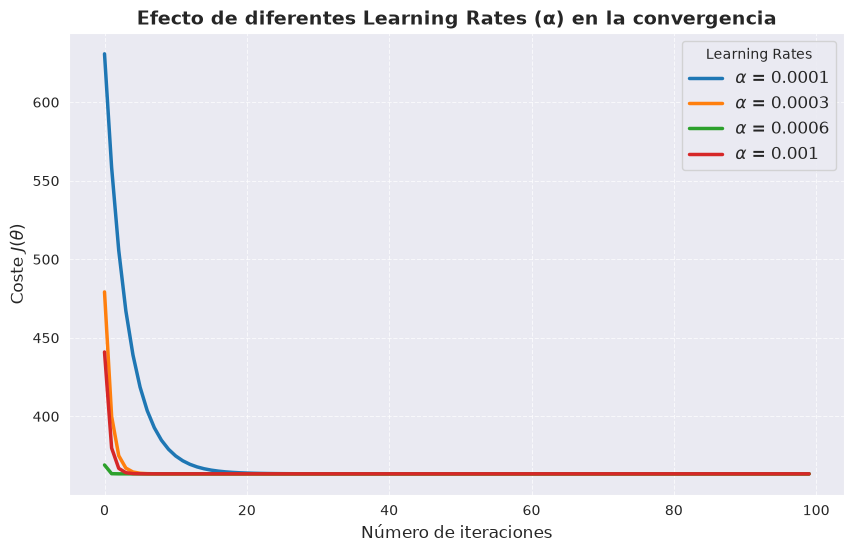

In [52]:
alphas = [0.0001, 0.0003, 0.0006, 0.001]
n_iteraciones = 100
theta_inicial = np.array([0.0, 0.0])

fig, ax = plt.subplots(figsize=(10, 6))

for alpha in alphas:
    _, historial_coste, _ = descenso_gradiente(X, y, theta_inicial, alpha, n_iteraciones)
    ax.plot(range(n_iteraciones), historial_coste, label=rf'$\alpha$ = {alpha}', linewidth=2.5)

ax.set_xlabel('Número de iteraciones', fontsize=12)
ax.set_ylabel(r'Coste $J(\theta)$', fontsize=12)
ax.set_title('Efecto de diferentes Learning Rates (α) en la convergencia', fontsize=14, fontweight='bold')
ax.legend(fontsize=12, title="Learning Rates", loc='upper right')
ax.grid(True, linestyle='--', alpha=0.7)

plt.show()

## 12. El Efecto de las iteraciones al error medio
A continuación, observaremos cómo varía el error medio al modificar el número de iteraciones. De forma intuitiva, podríamos concluir que existe una relación inversamente proporcional entre el número de iteraciones y el error medio: a medida que aumentan las iteraciones, el error disminuye. Sin embargo, llegará un punto en el que incrementar aún más el número de iteraciones no aportará una mejora significativa en el rendimiento.


Iteraciones: 1 | Error medio train (1450): 383,694.28 € | Error medio test (10): 380,221.65 €
Iteraciones: 2 | Error medio train (1450): 201,110.82 € | Error medio test (10): 204,053.38 €
Iteraciones: 3 | Error medio train (1450): 106,450.43 € | Error medio test (10): 101,237.06 €
Iteraciones: 4 | Error medio train (1450): 66,080.05 € | Error medio test (10): 67,204.97 €
Iteraciones: 5 | Error medio train (1450): 44,922.36 € | Error medio test (10): 40,013.14 €
Iteraciones: 6 | Error medio train (1450): 40,790.53 € | Error medio test (10): 39,491.16 €
Iteraciones: 7 | Error medio train (1450): 38,073.95 € | Error medio test (10): 34,186.87 €
Iteraciones: 8 | Error medio train (1450): 38,007.16 € | Error medio test (10): 35,098.60 €
Iteraciones: 9 | Error medio train (1450): 37,619.03 € | Error medio test (10): 33,839.60 €
Iteraciones: 10 | Error medio train (1450): 37,696.29 € | Error medio test (10): 34,484.52 €
Iteraciones: 100 | Error medio train (1450): 37,656.33 € | Error medio te

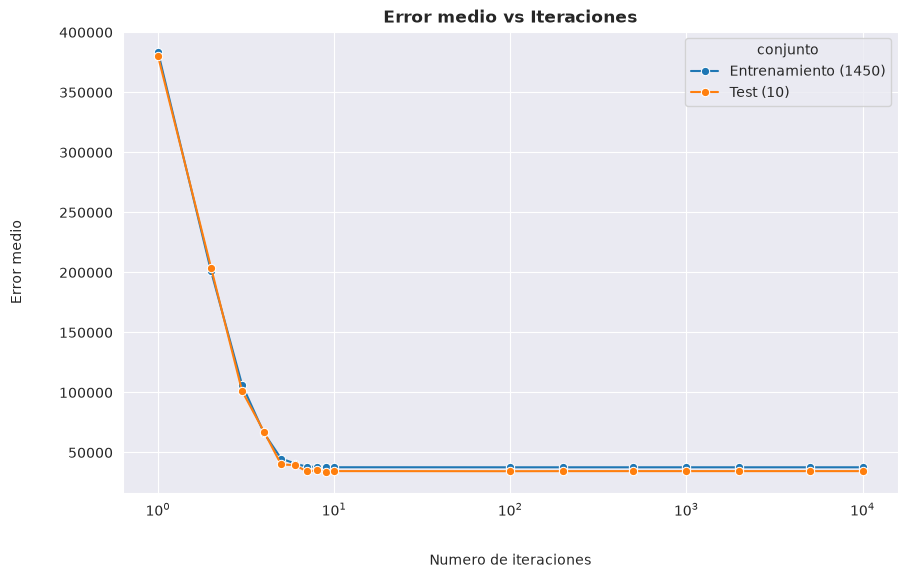

In [53]:
test = pd.read_csv("casas.csv")

x_min = test["GrLivArea"].iloc[:1450].min()
x_max = test["GrLivArea"].iloc[:1450].max()
y_min = test["SalePrice"].iloc[:1450].min()
y_max = test["SalePrice"].iloc[:1450].max()

tamaño_norm = (test["GrLivArea"].values[:1450] - x_min) / (x_max - x_min)
X = np.column_stack((np.ones(1450), tamaño_norm))
y = (test["SalePrice"].values[:1450] - y_min) / (y_max - y_min)

theta = np.ones(2)

iteraciones_lista = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10 ,100, 200, 500, 1000, 2000, 5000, 10000]
errores_train = []
errores_test = []

for n_iter in iteraciones_lista:
    recta_n = batch(0.001, theta, X, y, n_iteraciones=n_iter)
    predicciones_train_norm = hipotesis(X, recta_n)
    predicciones_train = predicciones_train_norm*(y_max - y_min) + y_min
    reales_train = test.iloc[:1450]["SalePrice"].values
    error_train = np.mean(np.abs(predicciones_train - reales_train))
    errores_train.append(error_train)

    total_error_test = 0
    for j in range(1450, 1460):
        grlivarea_real = test.iloc[j]["GrLivArea"]
        grlivarea_norm = (grlivarea_real - x_min) / (x_max - x_min)
        precio = hipotesis(theta=recta_n, X=np.array([1, grlivarea_norm]))
        precio_desnormalizado = precio*(y_max - y_min) + y_min
        original = test.iloc[j]["SalePrice"]
        total_error_test += abs(precio_desnormalizado - original)
    error_test = total_error_test / 10
    errores_test.append(error_test)

    print(f"Iteraciones: {n_iter} | Error medio train (1450): {error_train:,.2f} € | Error medio test (10): {error_test:,.2f} €")

df_errores = pd.DataFrame({"iteraciones": iteraciones_lista*2, "error": errores_train + errores_test,"conjunto": ["Entrenamiento (1450)"]*len(iteraciones_lista) + ["Test (10)"]*len(iteraciones_lista)})
plt.figure(figsize=(10, 6))
sns.lineplot(x="iteraciones",  y="error", data=df_errores, hue="conjunto", marker='o')
plt.xlabel("Numero de iteraciones", labelpad=25)
plt.ylabel("Error medio",labelpad=25)
plt.title("Error medio vs Iteraciones", fontweight="bold")
plt.xscale("log")
plt.show()  

La gráfica muestra el clásico patrón en forma de "L" de un descenso de gradiente:

1. Caída inicial muy pronunciada (iteraciones 1-8): el error pasa de más de 380.000€ a poco más de 38.000€ en apenas 8 pasos. Aquí es donde $\theta$ se mueve la mayor parte del camino hacia el mínimo.

2. Estabilización (a partir de 10 iteraciones): el error se aplana en torno a 37.663€ (entrenamiento) y 34.477€ (test), y a partir de la iteración 1000 los valores ya no cambian ni en el segundo decimal. Esto indica que el algoritmo ha convergido: theta ha llegado (o está prácticamente en) el mínimo de $J(\theta)$, y seguir iterando no aporta ninguna mejora.

3. Entrenamiento y test se comportan igual: las dos curvas están prácticamente superpuestas en todo momento. Con un único feature (GrLivArea) el modelo es demasiado simple para sobreajustar (**overfitting**), así que generaliza igual de bien a los datos que no ha visto.

## 13. Probando con mas features

In [54]:
original = pd.read_csv("casas.csv")
ejemplos_de_prueba = 1450

test = original.select_dtypes(include=np.number).copy()
test.drop("Id", axis=1, inplace=True)
test.drop("SalePrice", axis=1, inplace=True)
test.drop("LotFrontage", axis=1, inplace=True)

X_mins = test.min()
X_maxs = test.max()

test_norm = (test - X_mins) / (X_maxs - X_mins)
test_norm.fillna(test_norm.mean(), inplace=True)

X = np.ones((ejemplos_de_prueba, 1))
for column in test_norm.columns:
    X = np.column_stack((X, test_norm[column][:ejemplos_de_prueba]))
theta = np.zeros(len(test_norm.columns) + 1)

y = original["SalePrice"].values[:ejemplos_de_prueba]
y_min = original["SalePrice"].min()
y_max = original["SalePrice"].max()
y_norm = (y - y_min) / (y_max - y_min)
recta = batch(alfa=0.0001, theta=theta, X=X, y=y_norm)

---- Descenso de gradiente por BATCH (Todas las variables numéricas) ----
El precio predicho es 105679.32, el precio real es 136000, el error es 30320.68
El precio predicho es 253575.06, el precio real es 287090, el error es 33514.94
El precio predicho es 127184.29, el precio real es 145000, el error es 17815.71
El precio predicho es 115277.43, el precio real es 84500, el error es 30777.43
El precio predicho es 203080.53, el precio real es 185000, el error es 18080.53
El precio predicho es 188026.23, el precio real es 175000, el error es 13026.23
El precio predicho es 247085.34, el precio real es 210000, el error es 37085.34
El precio predicho es 222774.67, el precio real es 266500, el error es 43725.33
El precio predicho es 137188.01, el precio real es 142125, el error es 4936.99
El precio predicho es 159394.71, el precio real es 147500, el error es 11894.71

El error medio es 24117.789286579555


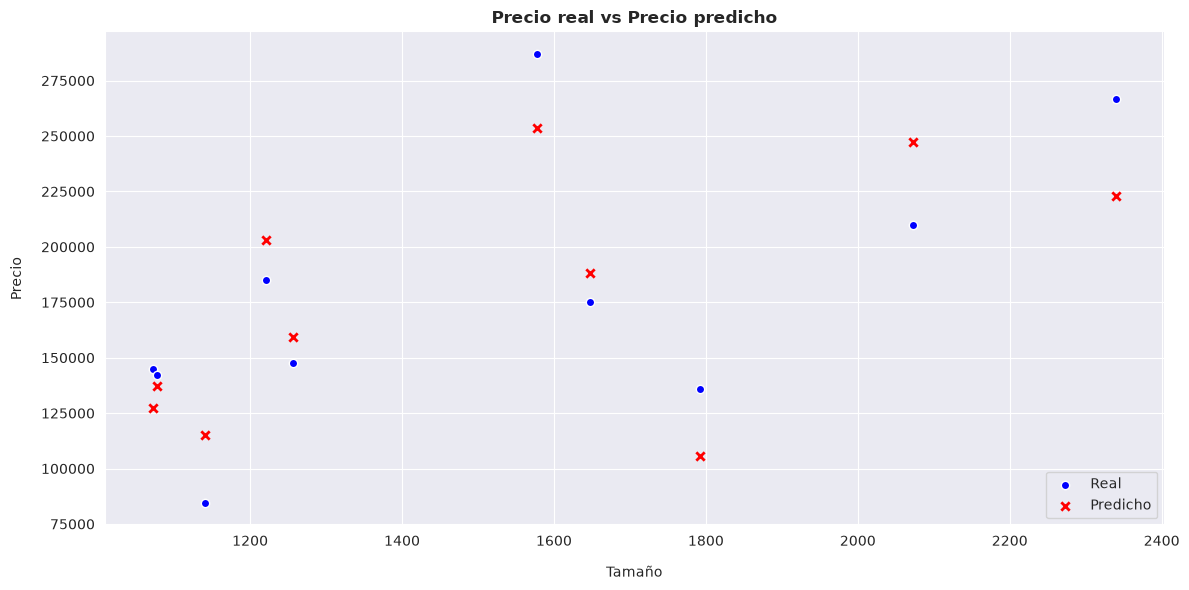

In [55]:
print("---- Descenso de gradiente por BATCH (Todas las variables numéricas) ----")
error_total = 0
lista_reales = []
lista_predicciones = []
for i in range(1450, 1460):
    valores = test.iloc[i].values
    divisor = X_maxs.values - X_mins.values
    divisor[divisor == 0] = 1 
    valores_norm = (valores - X_mins.values) / divisor
    valores_norm = np.nan_to_num(valores_norm, nan=0.0, posinf=0.0, neginf=0.0)
    
    precio_predicho_norm = hipotesis(theta=recta, X=np.concatenate(([1.0], valores_norm)))
    precio_predicho = (precio_predicho_norm * (y_max - y_min)) + y_min
    lista_predicciones.append(precio_predicho)
    
    precio_real = original.iloc[i]["SalePrice"]
    lista_reales.append(precio_real)
    error = abs(precio_predicho - precio_real)
    error_total += error
    print(f"El precio predicho es {precio_predicho:.2f}, el precio real es {precio_real}, el error es {error:.2f}")
print(f"\nEl error medio es {error_total/10}")

plt.figure(figsize=(12,6))
y = test.iloc[1450:]["GrLivArea"]
sns.scatterplot(x=y, y=lista_reales, marker='o', color="blue",linewidth=1, label="Real")
sns.scatterplot(x=y, y=lista_predicciones, marker='x', color="red", linewidth=2, label="Predicho")
plt.title("Precio real vs Precio predicho", fontweight="bold")
plt.xlabel("Tamaño",  labelpad=12)
plt.ylabel("Precio", labelpad=12)
plt.tight_layout()
plt.legend(loc="lower right")
plt.show()


### Conclusión: el impacto de añadir múltiples variables

Como se puede observar de manera clara en los resultados, al incorporar **todas las características numéricas** al entrenamiento en lugar de usar solo una, hemos logrado reducir el error medio de nuestras predicciones en aproximadamente **10.000 euros**. 

Al proporcionarle al algoritmo mucha más información contextual sobre las viviendas, el descenso de gradiente ha podido ajustar los pesos $\theta$ de forma mucho más rigurosa. Gracias a esta mejora, el margen de fallo se ha reducido drásticamente, por lo que podemos concluir que **este ya es un modelo bastante acertado** y robusto para la predicción de precios.

## 14. La Ecuación Normal

Hasta ahora hemos calculado $\theta$ de forma **iterativa**, con el descenso de gradiente: partimos de un $\theta$ inicial y lo vamos corrigiendo paso a paso hasta acercarnos al mínimo de $J(\theta)$. Existe una alternativa: la **Ecuación Normal**, que calcula el $\theta$ óptimo **directamente**, en un solo paso, sin necesidad de elegir un *learning rate* ni un número de iteraciones.

**Recordatorio: ¿qué es la regresión lineal?**

La regresión lineal busca la relación lineal entre unas variables de entrada (*features*) $X$ y una variable de salida $y$, mediante $h_\theta(x) = X\theta$. "Entrenar" el modelo significa encontrar el vector de parámetros $\theta$ que hace que las predicciones $h_\theta(x)$ se acerquen lo máximo posible a los valores reales $y$, minimizando la función de coste $J(\theta)$. El descenso de gradiente y la Ecuación Normal son simplemente **dos caminos distintos** para llegar al mismo destino: el $\theta$ que minimiza $J(\theta)$.

### Derivación

Partimos de la función de coste en su forma vectorizada:

$$J(\theta) = \frac{1}{2}(X\theta - y)^T(X\theta - y)$$

donde $X\theta$ son las predicciones, $y$ los valores reales, y $X\theta - y$ el vector de errores.

**Paso 1: Derivamos respecto a $\theta$:**

$$\nabla_\theta J(\theta) = X^T(X\theta - y)$$

**Paso 2: Igualamos a cero** (condición para encontrar el mínimo):

$$X^T(X\theta - y) = 0$$

**Paso 3: Desarrollamos y despejamos:**

$$X^TX\theta - X^Ty = 0 \quad\Rightarrow\quad X^TX\theta = X^Ty$$

**Paso 4: Aislamos $\theta$**, multiplicando ambos lados por $(X^TX)^{-1}$, asumiendo que $X^TX$ es invertible:

$$\boxed{\theta = (X^TX)^{-1}X^Ty}$$

Esa es la Ecuación Normal: nos da directamente el $\theta$ óptimo, sin iterar.


Reutilizamos la misma matriz `X` y el vector `y_norm` (normalizados) que construimos en la sección 13, con todas las variables numéricas, para poder comparar en igualdad de condiciones con el descenso de gradiente.

In [56]:
theta_normal = np.linalg.pinv(X.T @ X) @ X.T @ y_norm

print("Theta obtenido con la Ecuación Normal:")
print(theta_normal)

Theta obtenido con la Ecuación Normal:
[-0.1199895  -0.04109517  0.12330901  0.21550326  0.05149275  0.05176368
  0.01121735  0.06972027  0.07948939 -0.00172833  0.00145369  0.07356569
  0.1614283   0.07605526  0.00204145  0.16234483  0.0396978   0.00602451
  0.01511981 -0.00508067 -0.11456022 -0.05379454  0.08427441  0.01584508
  0.01905684  0.06314572 -0.01164544  0.03045007 -0.00200588  0.0091179
  0.01342787  0.03816094 -0.03341469 -0.02101186 -0.00069033 -0.00474245]


### Evaluación y comparación con el Descenso de Gradiente

Probamos la Ecuación Normal sobre los mismos 10 ejemplos de test que usamos en la sección 13, y comparamos su error medio con el que obtuvo el descenso de gradiente Batch.

In [57]:
print("---- Predicción con la Ecuación Normal (Todas las variables numéricas) ----")
error_total_normal = 0
lista_predicciones_normal = []
for i in range(1450, 1460):
    valores = test.iloc[i].values
    divisor = X_maxs.values - X_mins.values
    divisor[divisor == 0] = 1
    valores_norm = (valores - X_mins.values) / divisor
    valores_norm = np.nan_to_num(valores_norm, nan=0.0, posinf=0.0, neginf=0.0)

    precio_predicho_norm = hipotesis(theta=theta_normal, X=np.concatenate(([1.0], valores_norm)))
    precio_predicho = (precio_predicho_norm*(y_max - y_min)) + y_min
    lista_predicciones_normal.append(precio_predicho)

    precio_real = original.iloc[i]["SalePrice"]
    error = abs(precio_predicho - precio_real)
    error_total_normal += error
    print(f"El precio predicho es {precio_predicho:.2f}, el precio real es {precio_real}, el error es {error:.2f}")

error_medio_normal = error_total_normal / 10
print(f"\nEl error medio con la Ecuación Normal es {error_medio_normal:.2f}")

print("\n---- Comparación ----")
print(f"Error medio Descenso de Gradiente (Batch): {error_total/10:.2f} €")
print(f"Error medio Ecuación Normal:                {error_medio_normal:.2f} €")

---- Predicción con la Ecuación Normal (Todas las variables numéricas) ----
El precio predicho es 101481.97, el precio real es 136000, el error es 34518.03
El precio predicho es 248998.89, el precio real es 287090, el error es 38091.11
El precio predicho es 128477.06, el precio real es 145000, el error es 16522.94
El precio predicho es 116503.37, el precio real es 84500, el error es 32003.37
El precio predicho es 207984.28, el precio real es 185000, el error es 22984.28
El precio predicho es 184352.40, el precio real es 175000, el error es 9352.40
El precio predicho es 247297.80, el precio real es 210000, el error es 37297.80
El precio predicho es 225303.81, el precio real es 266500, el error es 41196.19
El precio predicho es 134727.21, el precio real es 142125, el error es 7397.79
El precio predicho es 157660.48, el precio real es 147500, el error es 10160.48

El error medio con la Ecuación Normal es 24952.44

---- Comparación ----
Error medio Descenso de Gradiente (Batch): 24117.79 €

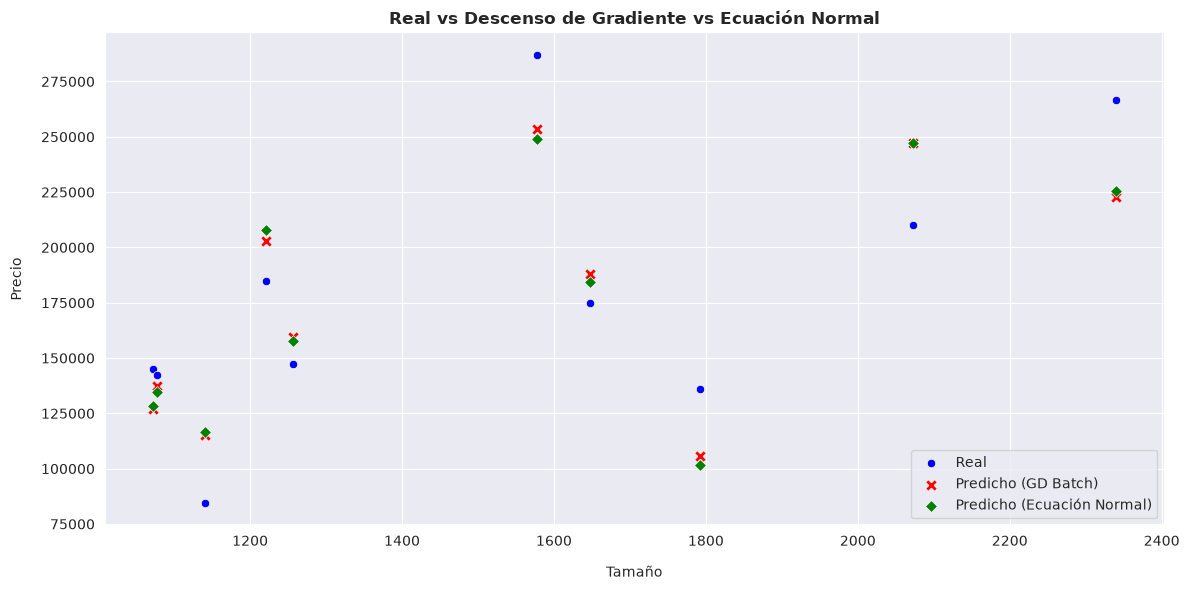

In [58]:
y_tamaño = test.iloc[1450:]["GrLivArea"]

plt.figure(figsize=(12, 6))
sns.scatterplot(x=y_tamaño, y=lista_reales, marker='o', color="blue", label="Real")
sns.scatterplot(x=y_tamaño, y=lista_predicciones, marker='x', color="red", linewidth=2, label="Predicho (GD Batch)")
sns.scatterplot(x=y_tamaño, y=lista_predicciones_normal, marker='D', color="green", label="Predicho (Ecuación Normal)")
plt.title("Real vs Descenso de Gradiente vs Ecuación Normal", fontweight="bold")
plt.xlabel("Tamaño", labelpad=12)
plt.ylabel("Precio", labelpad=12)
plt.tight_layout()
plt.legend(loc="lower right")
plt.show()

### Descenso de Gradiente vs Ecuación Normal

Como se observa, ambos métodos llegan a un error medio muy similar — tiene sentido, porque los dos están resolviendo el mismo problema de minimización, solo que por caminos distintos.

| | Descenso de Gradiente | Ecuación Normal |
|---|---|---|
| Tipo de solución | Iterativa (se acerca poco a poco) | Analítica / cerrada (exacta, un solo paso) |
| Hiperparámetros | Necesita elegir $\alpha$ y el número de iteraciones | No necesita ninguno |
| Normalización de features | Muy recomendable (acelera la convergencia) | No es necesaria para que funcione |
| Coste computacional | Barato por iteración, pero necesita muchas iteraciones | Una sola operación, pero calcular $(X^TX)^{-1}$ cuesta $O(n^3)$ con $n$ = número de features |
| Escalabilidad | Funciona bien incluso con miles de features o millones de ejemplos | Se vuelve muy lento con muchos features (invertir una matriz grande es costoso) |

**En la práctica:** con pocos features (como en este dataset), la Ecuación Normal es más rápida y directa. Pero si tuviéramos miles de features, el coste de invertir $X^TX$ sería demasiado alto, y el descenso de gradiente (sobre todo Mini-Batch) sería la opción más razonable.

## 15. Comparación con *scikit-learn*

,Valor real,Prediccion sklearn,Prediccion batch,Error sklearn,Error batch
0,136000,210593.536104,210593.535744,74593.536104,74593.535744
1,287090,187650.039972,187650.039902,99439.960028,99439.960098
2,145000,133400.465003,133400.465620,11599.534997,11599.534380
3,84500,140690.921718,140690.922243,56190.921718,56190.922243
4,185000,149375.142217,149375.142632,35624.857783,35624.857368
5,175000,195047.709285,195047.709122,20047.709285,20047.709122
6,210000,240720.276354,240720.275612,30720.276354,30720.275612
7,266500,269346.040220,269346.039116,2846.040220,2846.039116
8,142125,134043.740596,134043.741205,8081.259404,8081.258795
9,147500,153127.583173,153127.583541,5627.583173,5627.583541


Error medio sklearn: 34477.17
Error medio batch: 34477.17


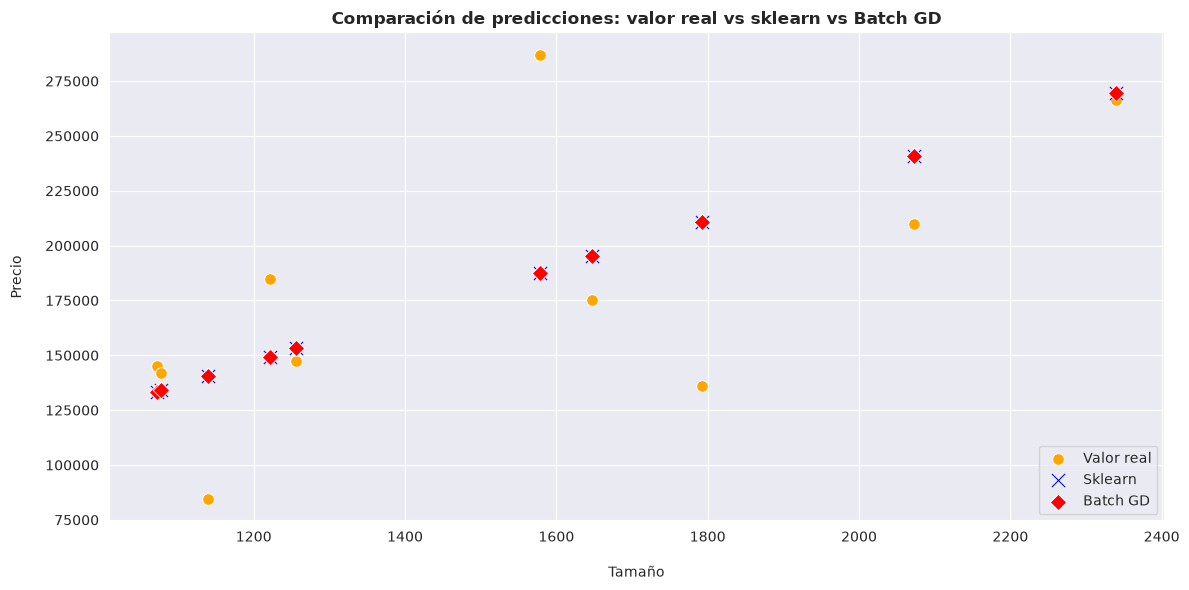

In [60]:
from sklearn import linear_model

x_train_raw = original["GrLivArea"].values[:1450]
y_train_raw = original["SalePrice"].values[:1450]
x_train_norm = ((x_train_raw - x_min) / (x_max - x_min)).reshape(-1, 1)
y_train_norm = (y_train_raw - y_min) / (y_max - y_min)

x_test_raw = original["GrLivArea"].values[1450:].reshape(-1, 1)
x_test_norm = (x_test_raw.ravel() - x_min) / (x_max - x_min)
y_real = original["SalePrice"].values[1450:]

modelo_sklearn = linear_model.LinearRegression().fit(x_train_norm, y_train_norm)
pred_sklearn_norm = modelo_sklearn.predict(x_test_norm.reshape(-1, 1))
pred_sklearn = pred_sklearn_norm*(y_max - y_min) + y_min

pred_batch_norm = recta_batch[0] + recta_batch[1]*x_test_norm
pred_batch = pred_batch_norm*(y_max - y_min) + y_min

comparacion = pd.DataFrame({
    "Valor real": y_real,
    "Prediccion sklearn": pred_sklearn,
    "Prediccion batch": pred_batch,
    "Error sklearn": np.abs(y_real - pred_sklearn),
    "Error batch": np.abs(y_real - pred_batch)
})

display(comparacion)

print(f"Error medio sklearn: {comparacion['Error sklearn'].mean():.2f}")
print(f"Error medio batch: {comparacion['Error batch'].mean():.2f}")

plt.figure(figsize=(12, 6))
sns.scatterplot(x=x_test_raw.ravel(), y=y_real, label="Valor real", color="orange", s=70)
sns.scatterplot(x=x_test_raw.ravel(), y=pred_sklearn, label="Sklearn", color="blue", marker="x", s=90)
sns.scatterplot(x=x_test_raw.ravel(), y=pred_batch, label="Batch GD", color="red", marker="D", s=70)
plt.title("Comparación de predicciones: valor real vs sklearn vs Batch GD", fontweight="bold")
plt.xlabel("Tamaño", labelpad=15)
plt.ylabel("Precio", labelpad=15)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 16. Resumen

---

### Lo que hemos implementado

| Componente | Fórmula | Código |
|-----------|---------|--------|
| Hipótesis | $h_\theta(x) = X\theta$ | `X @ theta` |
| Coste | $J(\theta) = \frac{1}{2}\sum(h_\theta(x^{(i)}) - y^{(i)})^2$ | `(1/2) * sum(errores²)` |
| Gradiente | $X^T(h_\theta(X) - y)$ | `X.T @ errores` |
| Actualización | $\theta := \theta - \alpha \nabla J$ | `theta -= alpha*grad` |

### Conclusiones clave

1. **Normalizar siempre** antes de aplicar GD, acelera muchísimo la convergencia
2. **Batch GD**: suave y estable, pero lento en datasets grandes
3. **SGD**: ruidoso pero puede ser más óptimo y escala bien
4. **Mini-Batch**: el mejor equilibrio en la práctica (usa potencias de 2)
5. El algoritmo **escala a cualquier número de features** sin cambiar el código
6. Probar valores distintos de **$\alpha$** para obtener los mejores resultados
7. La **Ecuación Normal** ofrece una alternativa analítica (sin iterar) al descenso de gradiente, ideal cuando el número de features es manejable

---
*Implementado sin librerías de ML*